In [1]:
############### Cell 1 - imports
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import MNIST

In [ ]:
############### Cell 2 - data (normalize to [-1, 1] for Gaussian likelihood)
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.Lambda(lambda x: x.view(-1)),
])

full_train_dataset = MNIST(root="./data", train=True, download=True, transform=transform)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
test_dataset = MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
############### Cell 3 - priors (logvar, NOT std, to keep variance positive)
z_dim, K = 16, 10

mu_prior     = nn.Parameter(torch.randn(K, z_dim) * 0.1)
logvar_prior = nn.Parameter(torch.zeros(K, z_dim))     # logvar=0 -> var=1
pi_k         = torch.full((K,), 1.0 / K)                # fixed uniform prior (NOT a Parameter)


In [ ]:
############### Cell 4 - Encoder (pi already softmaxed here)
class Encoder(nn.Module):
    def __init__(self, in_dim, hidden1, hidden2, z_dim, dim_cluster, dropout_p=0.2):
        super().__init__()
        self.z_dim = z_dim
        self.dim_cluster = dim_cluster

        self.feature_net = nn.Sequential(
            nn.Linear(in_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_p),
        )
        self.fc_mu       = nn.Linear(hidden2, z_dim * dim_cluster)
        self.fc_logvar   = nn.Linear(hidden2, z_dim * dim_cluster)
        self.fc_category = nn.Linear(hidden2, dim_cluster)

    def forward(self, x):
        h = self.feature_net(x)
        mu     = self.fc_mu(h).view(-1, self.dim_cluster, self.z_dim)
        logvar = self.fc_logvar(h).view(-1, self.dim_cluster, self.z_dim)
        pi     = torch.softmax(self.fc_category(h), dim=-1)   # already probabilities
        return mu, logvar, pi


In [ ]:
############### Cell 5 - bottleneck (NO second softmax; just sanitize + clamp)
def bottleneck(mu, logvar, pi, batch_size):
    logvar = torch.clamp(logvar, min=-10.0, max=10.0)       # prevent exp() blowup

    pi_safe = pi + 1e-8
    pi_safe = pi_safe / pi_safe.sum(dim=-1, keepdim=True)
    sampled_cluster = torch.multinomial(pi_safe, num_samples=1).squeeze(-1)

    idx = torch.arange(batch_size, device=mu.device)
    mu_     = mu[idx, sampled_cluster]
    logvar_ = logvar[idx, sampled_cluster]

    std = torch.exp(0.5 * logvar_)
    eps = torch.randn_like(std)
    z = mu_ + eps * std
    return z, sampled_cluster

In [ ]:
############### Cell 6 - Decoder (Gaussian likelihood => NO final activation, unbounded output)
class Decoder(nn.Module):
    def __init__(self, z_dim, hidden1, hidden2, in_dim, dropout_p=0.2):
        super().__init__()
        self.feature_net = nn.Sequential(
            nn.Linear(z_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden2, in_dim),      # no activation on final layer
        )
    def forward(self, sampled_z):
        return self.feature_net(sampled_z)

In [ ]:
############### Cell 7 - loss (takes logvar_prior, exponentiates internally)
def loss_function_unsupervised(
    reconstruction, x, mu, logvar, pi,
    mu_prior, logvar_prior, pi_k,
    sampled_cluster, beta=1.0, eps=1e-8,
):
    B = x.size(0)
    batch_idx = torch.arange(B, device=x.device)

    # 1. Reconstruction (Gaussian likelihood => MSE)
    recon_loss = F.mse_loss(reconstruction, x, reduction="sum") / B

    # 2. Gaussian KL on the sampled cluster
    mu_k     = mu[batch_idx, sampled_cluster]
    logvar_k = logvar[batch_idx, sampled_cluster]
    var_k    = logvar_k.exp()

    mu_p     = mu_prior[sampled_cluster]
    logvar_p = logvar_prior[sampled_cluster]
    var_p    = logvar_p.exp()

    kl_gauss = 0.5 * torch.sum(
        logvar_p - logvar_k + (var_k + (mu_k - mu_p) ** 2) / var_p - 1, dim=-1
    ).mean()

    # 3. Categorical KL: q(c|x) || p(c)
    kl_cat = torch.sum(
        pi * (torch.log(pi + eps) - torch.log(pi_k + eps)), dim=-1
    ).mean()

    return recon_loss + beta * (kl_gauss + kl_cat)

In [ ]:
############### Cell 8 - validation
def evaluate(encoder, decoder, val_loader, mu_prior, logvar_prior, pi_k, beta):
    encoder.eval(); decoder.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            x = batch[0] if isinstance(batch, (list, tuple)) else batch
            B = x.size(0)
            mu, logvar, pi = encoder(x)
            z, sampled_cluster = bottleneck(mu, logvar, pi, B)
            reconstruction = decoder(z)
            loss = loss_function_unsupervised(
                reconstruction, x, mu, logvar, pi,
                mu_prior, logvar_prior, pi_k,
                sampled_cluster, beta,
            )
            total_loss += loss.item() * B
    return total_loss / len(val_loader.dataset)

In [ ]:
############### Cell 9 - training 


epochs = 160
warmup_epochs = 20
best_val_loss = float("inf")

encoder = Encoder(in_dim=784, hidden1=512, hidden2=256, z_dim=16, dim_cluster=10)
decoder = Decoder(z_dim=16, hidden1=256, hidden2=512, in_dim=784)

optimizer = optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()) + [mu_prior, logvar_prior],
    lr=1e-3,
)

beta = 0.0
train_losses, val_losses = [], []

for epoch in range(epochs):
    encoder.train(); decoder.train()
    running_loss = 0.0

    for batch in train_loader:
        x = batch[0] if isinstance(batch, (list, tuple)) else batch
        B = x.size(0)

        optimizer.zero_grad()
        mu, logvar, pi = encoder(x)
        z, sampled_cluster = bottleneck(mu, logvar, pi, B)
        reconstruction = decoder(z)
        loss = loss_function_unsupervised(
            reconstruction, x, mu, logvar, pi,
            mu_prior, logvar_prior, pi_k,
            sampled_cluster, beta,
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(decoder.parameters()) + [mu_prior, logvar_prior],
            max_norm=5.0,
        )
        optimizer.step()
        running_loss += loss.item() * B

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_val_loss   = evaluate(encoder, decoder, val_loader, mu_prior, logvar_prior, pi_k, beta)
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    beta = 0.2 * min(1.0, (epoch + 1) / warmup_epochs)

    print(f"Epoch {epoch:03d}: beta={beta:.2f}  train={epoch_train_loss:.4f}  val={epoch_val_loss:.4f}")

In [399]:
############### Cell 10 saving
torch.save({
    "encoder1": encoder.state_dict(),
    "decoder1": decoder.state_dict(),
    "mu_prior1": mu_prior.detach(),
    "logvar_prior1": logvar_prior.detach(),
},'model_weights_CNN.mah')
torch.save({'train':train_losses,'val':val_losses},'list_.mah')

In [401]:
############### Cell 11 loading 
blocks=torch.load('model_weights_CNN.mah')
lists=torch.load('list_.mah')
lists

{'train': 'train', 'val': 'val'}

In [ ]:
############### Cell 12 all the hidden priors pdf parameters #10
priors_mean=blocks['mu_prior1']
priors_logvar=blocks['logvar_prior1']

In [ ]:
############### Cell 13 sampling 
cluster=torch.multinomial(torch.ones(10)/10,1)
mu=blocks['mu_prior1'][cluster]
std=torch.exp(blocks['mu_prior1'][cluster]*0.5)
noise=torch.randn_like(mu)
sample={'sample':(std*noise)+mu,'cluster':cluster}


In [ ]:
############### Cell 14 generation
blocks=torch.load('model_weights_CNN.mah')
decoder =Decoder(z_dim=16, hidden1=256, hidden2=512, in_dim=784)                  # rebuild architecture
decoder.load_state_dict(blocks['decoder1'])     # load weights into it
decoder.eval()
with torch.no_grad():
    x_hat=decoder(sample['sample'])
# plt.figure(figsize=(0.5, 0.5))
# plt.imshow(reconstruction.reshape(28,28) )   

In [ ]:
############### Cell 15 hidden space pi,mu,logvar
encoder=Encoder(in_dim=784, hidden1=512, hidden2=256, z_dim=16, dim_cluster=10)
encoder.load_state_dict(blocks['encoder1'])
encoder.eval()
with torch.no_grad():
    hidden_output=encoder(torch.randn(784))

In [403]:
############### Cell 16 validation train loss plot 
# train_losses = lists["train"]
# val_losses   = lists["val"]

# # plot
# plt.figure(figsize=(8, 4))
# plt.plot(train_losses, label="train")
# plt.plot(val_losses, label="val")
# plt.xlabel("epoch")
# plt.ylabel("loss")
# plt.title("GM-VAE training curve")
# plt.legend()
# plt.tight_layout()

# plt.show()

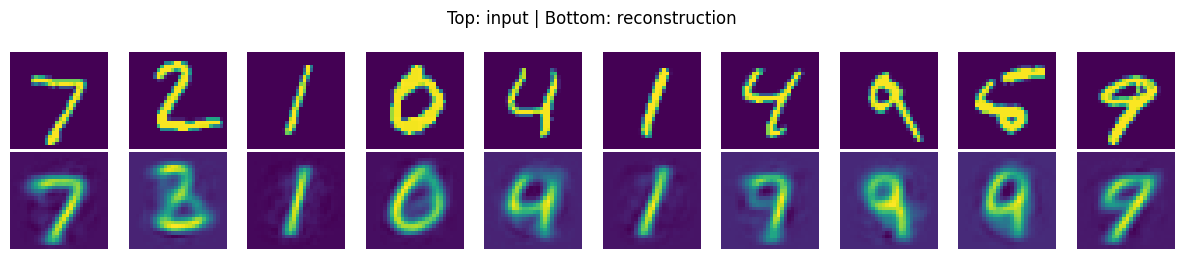

In [407]:
############### Cell 17  Reconstructions (input vs reconstructed)

x_batch, labels = next(iter(test_loader))
n_show = 10

with torch.no_grad():
    mu, logvar, pi = encoder(x_batch[:n_show])
    z, _ = bottleneck(mu, logvar, pi, batch_size=n_show)
    recon = decoder(z)

# plot
fig, axes = plt.subplots(2, n_show, figsize=(n_show * 1.2, 2.6))
for i in range(n_show):
    axes[0, i].imshow(x_batch[i].reshape(28, 28))
    axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].reshape(28, 28))
    axes[1, i].axis('off')
axes[0, 0].set_ylabel("input", fontsize=9)
axes[1, 0].set_ylabel("recon", fontsize=9)
plt.suptitle("Top: input | Bottom: reconstruction")
plt.tight_layout()

plt.show()

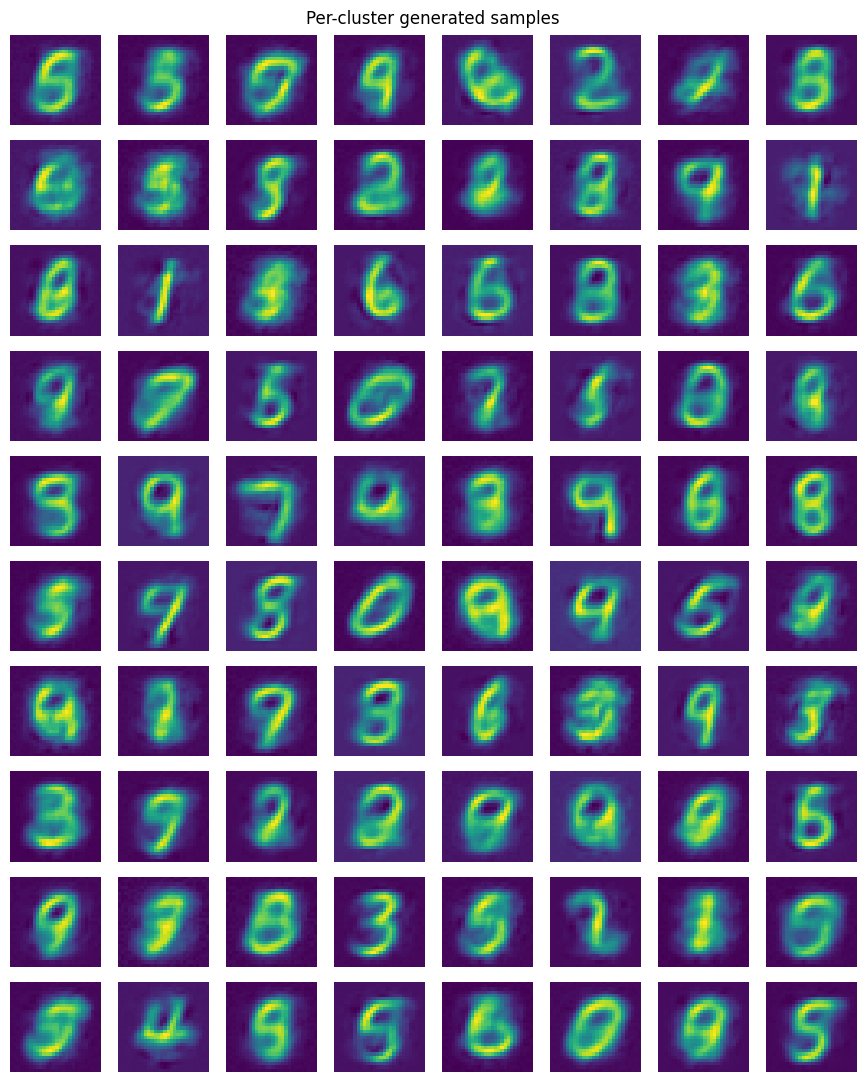

In [409]:
############### Cell 18 Per-cluster generated samples
mu_prior     = blocks['mu_prior1']      # [K, z_dim]
logvar_prior = blocks['logvar_prior1']  # [K, z_dim]

K = mu_prior.shape[0]
n_samples = 8

fig, axes = plt.subplots(K, n_samples, figsize=(n_samples * 1.1, K * 1.1))

with torch.no_grad():
    for k in range(K):
        mu_k  = mu_prior[k]
        std_k = torch.exp(0.5 * logvar_prior[k])
        for j in range(n_samples):
            z = mu_k + torch.randn_like(std_k) * std_k
            sample = decoder(z.unsqueeze(0))
            axes[k, j].imshow(sample.squeeze().reshape(28, 28))
            axes[k, j].axis('off')
        axes[k, 0].set_ylabel(f"c{k}", rotation=0, labelpad=15, fontsize=8)

plt.suptitle("Per-cluster generated samples")
plt.tight_layout()
plt.show()

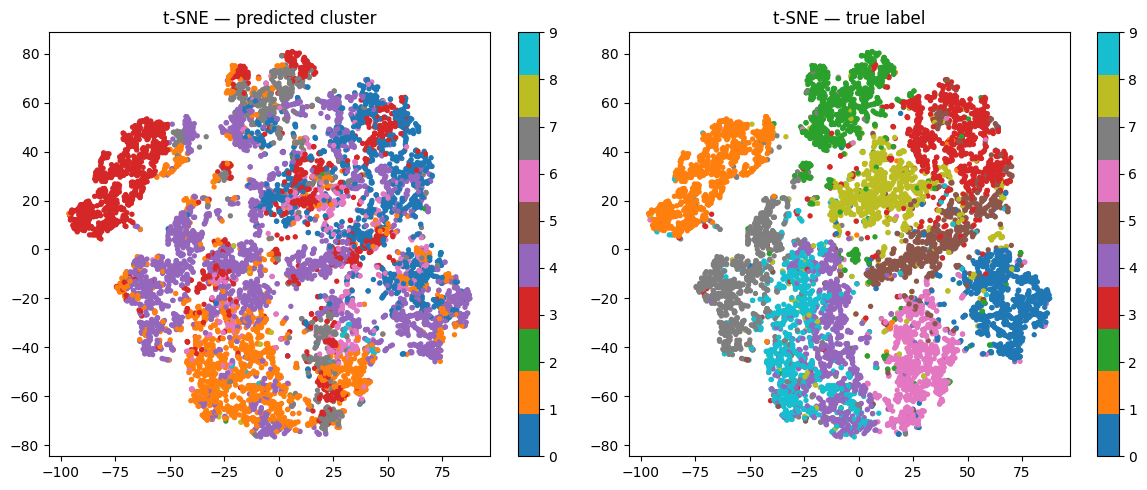

In [412]:
############### Cell 19  t-SNE latent space visualization (predicted cluster vs true label)
from sklearn.manifold import TSNE

# load model
blocks = torch.load('model_weights_CNN.mah', map_location='cpu')
encoder = Encoder(in_dim=784, hidden1=512, hidden2=256, z_dim=16, dim_cluster=10)
encoder.load_state_dict(blocks['encoder1'])
encoder.eval()

# collect latents + labels from test set
all_z, all_pred_cluster, all_true_label = [], [], []

with torch.no_grad():
    for x, labels in test_loader:
        mu, logvar, pi = encoder(x)
        pred_cluster = pi.argmax(dim=-1)
        idx = torch.arange(x.size(0))
        mu_sel = mu[idx, pred_cluster]   # deterministic z = mean of chosen cluster

        all_z.append(mu_sel.numpy())
        all_pred_cluster.append(pred_cluster.numpy())
        all_true_label.append(labels.numpy())

all_z           = np.concatenate(all_z)
all_pred_cluster = np.concatenate(all_pred_cluster)
all_true_label   = np.concatenate(all_true_label)

# t-SNE
z_2d = TSNE(n_components=2, random_state=0, perplexity=30).fit_transform(all_z)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc0 = axes[0].scatter(z_2d[:, 0], z_2d[:, 1], c=all_pred_cluster, cmap='tab10', s=8)
axes[0].set_title("t-SNE — predicted cluster")
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(z_2d[:, 0], z_2d[:, 1], c=all_true_label, cmap='tab10', s=8)
axes[1].set_title("t-SNE — true label")
plt.colorbar(sc1, ax=axes[1])

plt.tight_layout()
plt.show()

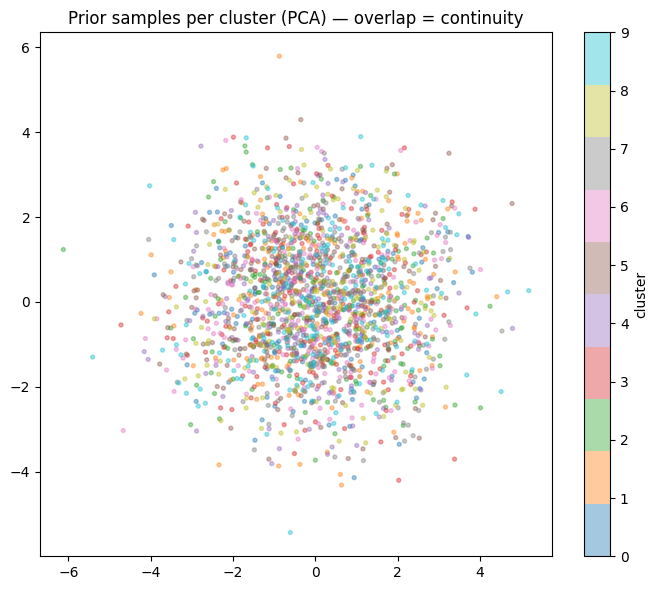

In [413]:
############### Cell 20 Cluster overlap plot (Bhattacharyya / PCA) continouty of hidden space 
from sklearn.decomposition import PCA

# load priors
blocks       = torch.load('model_weights_CNN.mah', map_location='cpu')
mu_prior     = blocks['mu_prior1']      # [K, z_dim]
logvar_prior = blocks['logvar_prior1']  # [K, z_dim]

K = mu_prior.shape[0]
n_samples_per_cluster = 200

all_z, all_labels = [], []

with torch.no_grad():
    for k in range(K):
        mu_k  = mu_prior[k]
        std_k = torch.exp(0.5 * logvar_prior[k])
        z = mu_k + torch.randn(n_samples_per_cluster, mu_k.shape[0]) * std_k
        all_z.append(z.numpy())
        all_labels.append(np.full(n_samples_per_cluster, k))

all_z      = np.concatenate(all_z)
all_labels = np.concatenate(all_labels)

# PCA to 2D
z_2d = PCA(n_components=2).fit_transform(all_z)

plt.figure(figsize=(7, 6))
sc = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=all_labels, cmap='tab10', s=8, alpha=0.4)
plt.colorbar(sc, label='cluster')
plt.title("Prior samples per cluster (PCA) — overlap = continuity")
plt.tight_layout()
plt.show()

In [415]:
############### Cell 21  Cluster purity, NMI, ARI
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from scipy.optimize import linear_sum_assignment

# load model
blocks = torch.load('model_weights_CNN.mah', map_location='cpu')
encoder = Encoder(in_dim=784, hidden1=512, hidden2=256, z_dim=16, dim_cluster=10)
encoder.load_state_dict(blocks['encoder1'])
encoder.eval()

# collect predictions
all_pred_cluster, all_true_label = [], []

with torch.no_grad():
    for x, labels in test_loader:
        mu, logvar, pi = encoder(x)
        pred_cluster = pi.argmax(dim=-1)
        all_pred_cluster.append(pred_cluster.numpy())
        all_true_label.append(labels.numpy())

all_pred_cluster = np.concatenate(all_pred_cluster)
all_true_label   = np.concatenate(all_true_label)

# cluster purity
def cluster_purity(pred, true):
    total_correct = 0
    for k in np.unique(pred):
        mask = pred == k
        majority = np.bincount(true[mask]).argmax()
        total_correct += (true[mask] == majority).sum()
    return total_correct / len(true)

purity = cluster_purity(all_pred_cluster, all_true_label)
nmi    = normalized_mutual_info_score(all_true_label, all_pred_cluster)
ari    = adjusted_rand_score(all_true_label, all_pred_cluster)

print(f"Cluster Purity : {purity:.4f}")
print(f"NMI            : {nmi:.4f}")
print(f"ARI            : {ari:.4f}")

Cluster Purity : 0.3280
NMI            : 0.2215
ARI            : 0.1288


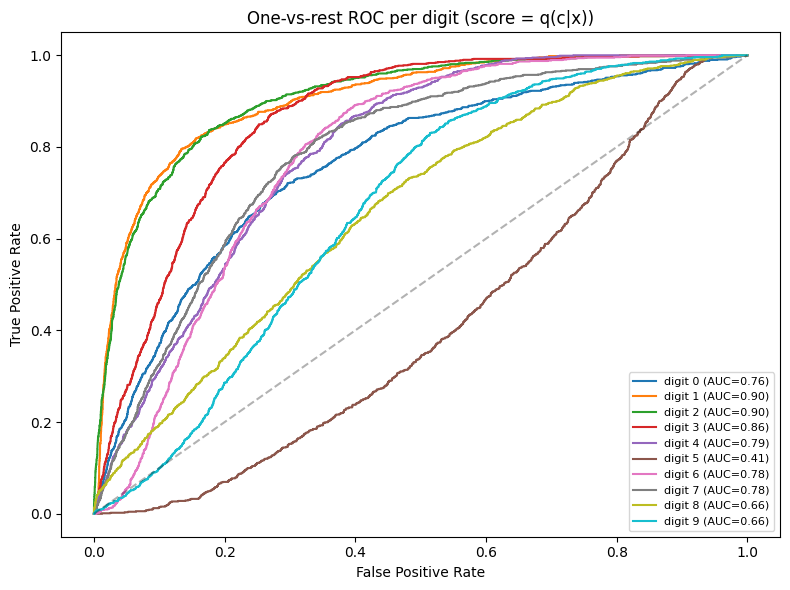

Macro AUC: 0.7517


In [416]:
############### Cell 22  ROC / AUC per class
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.optimize import linear_sum_assignment

# load model
blocks = torch.load('model_weights_CNN.mah', map_location='cpu')
encoder = Encoder(in_dim=784, hidden1=512, hidden2=256, z_dim=16, dim_cluster=10)
encoder.load_state_dict(blocks['encoder1'])
encoder.eval()

# collect pi (soft assignments) + true labels
all_pi, all_true_label = [], []

with torch.no_grad():
    for x, labels in test_loader:
        mu, logvar, pi = encoder(x)
        all_pi.append(pi.numpy())
        all_true_label.append(labels.numpy())

all_pi         = np.concatenate(all_pi)           # [N, K]
all_true_label = np.concatenate(all_true_label)   # [N]

# align cluster indices to true labels via Hungarian algorithm
pred_cluster = all_pi.argmax(axis=1)
confusion    = np.zeros((10, 10), dtype=int)
for p, t in zip(pred_cluster, all_true_label):
    confusion[p, t] += 1
row_ind, col_ind = linear_sum_assignment(-confusion)
alignment = dict(zip(row_ind, col_ind))   # cluster_idx -> digit_label

# reorder pi columns to match true label order
aligned_scores = np.zeros_like(all_pi)
for cluster_idx, label_idx in alignment.items():
    aligned_scores[:, label_idx] = all_pi[:, cluster_idx]

# plot ROC per digit
plt.figure(figsize=(8, 6))
aucs = {}
for label in range(10):
    y_binary = (all_true_label == label).astype(int)
    y_score  = aligned_scores[:, label]
    fpr, tpr, _ = roc_curve(y_binary, y_score)
    auc = roc_auc_score(y_binary, y_score)
    aucs[label] = auc
    plt.plot(fpr, tpr, label=f"digit {label} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-rest ROC per digit (score = q(c|x))")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

macro_auc = np.mean(list(aucs.values()))
print(f"Macro AUC: {macro_auc:.4f}")

In [ ]:
##  beta 
############### Cell 1 - imports
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import MNIST


############### Cell 2 - data (normalize to [-1, 1] for Gaussian likelihood)
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.Lambda(lambda x: x.view(-1)),
])

full_train_dataset = MNIST(root="./data", train=True, download=True, transform=transform)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
test_dataset = MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


############### Cell 3 - priors (logvar, NOT std, to keep variance positive)
z_dim, K = 16, 10

mu_prior     = nn.Parameter(torch.randn(K, z_dim) * 0.1)
logvar_prior = nn.Parameter(torch.zeros(K, z_dim))     # logvar=0 -> var=1
pi_k         = torch.full((K,), 1.0 / K)                # fixed uniform prior (NOT a Parameter)


############### Cell 4 - Encoder (pi already softmaxed here)
class Encoder(nn.Module):
    def __init__(self, in_dim, hidden1, hidden2, z_dim, dim_cluster, dropout_p=0.2):
        super().__init__()
        self.z_dim = z_dim
        self.dim_cluster = dim_cluster

        self.feature_net = nn.Sequential(
            nn.Linear(in_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_p),
        )
        self.fc_mu       = nn.Linear(hidden2, z_dim * dim_cluster)
        self.fc_logvar   = nn.Linear(hidden2, z_dim * dim_cluster)
        self.fc_category = nn.Linear(hidden2, dim_cluster)

    def forward(self, x):
        h = self.feature_net(x)
        mu     = self.fc_mu(h).view(-1, self.dim_cluster, self.z_dim)
        logvar = self.fc_logvar(h).view(-1, self.dim_cluster, self.z_dim)
        pi     = torch.softmax(self.fc_category(h), dim=-1)   # already probabilities
        return mu, logvar, pi


############### Cell 5 - bottleneck (NO second softmax; just sanitize + clamp)
def bottleneck(mu, logvar, pi, batch_size):
    logvar = torch.clamp(logvar, min=-10.0, max=10.0)       # prevent exp() blowup

    pi_safe = pi + 1e-8
    pi_safe = pi_safe / pi_safe.sum(dim=-1, keepdim=True)
    sampled_cluster = torch.multinomial(pi_safe, num_samples=1).squeeze(-1)

    idx = torch.arange(batch_size, device=mu.device)
    mu_     = mu[idx, sampled_cluster]
    logvar_ = logvar[idx, sampled_cluster]

    std = torch.exp(0.5 * logvar_)
    eps = torch.randn_like(std)
    z = mu_ + eps * std
    return z, sampled_cluster


############### Cell 6 - Decoder (Gaussian likelihood => NO final activation, unbounded output)
class Decoder(nn.Module):
    def __init__(self, z_dim, hidden1, hidden2, in_dim, dropout_p=0.2):
        super().__init__()
        self.feature_net = nn.Sequential(
            nn.Linear(z_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden2, in_dim),      # no activation on final layer
        )
    def forward(self, sampled_z):
        return self.feature_net(sampled_z)


############### Cell 7 - loss (takes logvar_prior, exponentiates internally)
def loss_function_unsupervised(
    reconstruction, x, mu, logvar, pi,
    mu_prior, logvar_prior, pi_k,
    sampled_cluster, beta=1.0, eps=1e-8,
):
    B = x.size(0)
    batch_idx = torch.arange(B, device=x.device)

    # 1. Reconstruction (Gaussian likelihood => MSE)
    recon_loss = F.mse_loss(reconstruction, x, reduction="sum") / B

    # 2. Gaussian KL on the sampled cluster
    mu_k     = mu[batch_idx, sampled_cluster]
    logvar_k = logvar[batch_idx, sampled_cluster]
    var_k    = logvar_k.exp()

    mu_p     = mu_prior[sampled_cluster]
    logvar_p = logvar_prior[sampled_cluster]
    var_p    = logvar_p.exp()

    kl_gauss = 0.5 * torch.sum(
        logvar_p - logvar_k + (var_k + (mu_k - mu_p) ** 2) / var_p - 1, dim=-1
    ).mean()

    # 3. Categorical KL: q(c|x) || p(c)
    kl_cat = torch.sum(
        pi * (torch.log(pi + eps) - torch.log(pi_k + eps)), dim=-1
    ).mean()

    return recon_loss + beta * (kl_gauss + kl_cat)


############### Cell 8 - validation
def evaluate(encoder, decoder, val_loader, mu_prior, logvar_prior, pi_k, beta):
    encoder.eval(); decoder.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            x = batch[0] if isinstance(batch, (list, tuple)) else batch
            B = x.size(0)
            mu, logvar, pi = encoder(x)
            z, sampled_cluster = bottleneck(mu, logvar, pi, B)
            reconstruction = decoder(z)
            loss = loss_function_unsupervised(
                reconstruction, x, mu, logvar, pi,
                mu_prior, logvar_prior, pi_k,
                sampled_cluster, beta,
            )
            total_loss += loss.item() * B
    return total_loss / len(val_loader.dataset)


############### Cell 9 - training + checkpoint to Google Drive


epochs = 160
warmup_epochs = 20
best_val_loss = float("inf")

encoder = Encoder(in_dim=784, hidden1=512, hidden2=256, z_dim=16, dim_cluster=10)
decoder = Decoder(z_dim=16, hidden1=256, hidden2=512, in_dim=784)

optimizer = optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()) + [mu_prior, logvar_prior],
    lr=1e-3,
)

beta = 0.0
train_losses, val_losses = [], []

for epoch in range(epochs):
    encoder.train(); decoder.train()
    running_loss = 0.0

    for batch in train_loader:
        x = batch[0] if isinstance(batch, (list, tuple)) else batch
        B = x.size(0)

        optimizer.zero_grad()
        mu, logvar, pi = encoder(x)
        z, sampled_cluster = bottleneck(mu, logvar, pi, B)
        reconstruction = decoder(z)
        loss = loss_function_unsupervised(
            reconstruction, x, mu, logvar, pi,
            mu_prior, logvar_prior, pi_k,
            sampled_cluster, beta,
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(decoder.parameters()) + [mu_prior, logvar_prior],
            max_norm=5.0,
        )
        optimizer.step()
        running_loss += loss.item() * B

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_val_loss   = evaluate(encoder, decoder, val_loader, mu_prior, logvar_prior, pi_k, beta)
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    beta = 0.2 * min(1.0, (epoch + 1) / warmup_epochs)

    print(f"Epoch {epoch:03d}: beta={beta:.2f}  train={epoch_train_loss:.4f}  val={epoch_val_loss:.4f}")

    